In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("cleaned_data.csv")

df.head()

Saving cleaned_data.csv to cleaned_data.csv


,title,descriptionHtml,propertyType,sizeSqFeetMax,bedrooms,bathrooms,listingUpdateReason,price,id,date_field,date_type,property_group,street,area,postcode,latitude,longitude,district,ward,constituency
0,"8 bedroom house for sale in Winnington Road, H...","This magnificent home, set behind security gat...",House,16749.0,8.0,8.0,new,24950000.0,9e2ceeb5-9197-4b23-b6dc-e578b8065514,10/10/2024,added_on,House,Winnington Road,Hampstead,N2,51.586178,-0.170121,Barnet,Garden Suburb,Finchley and Golders Green
1,"7 bedroom house for sale in Brick Street, Mayf...","In the heart of exclusive Mayfair, this majest...",House,12960.0,7.0,7.0,price_reduced,29500000.0,766eb673-019a-4921-8cc9-3deae886c06a,24/10/2024,reduced_on,House,Brick Street,Mayfair,W1J,51.509539,-0.136100,Westminster,West End,Cities of London and Westminster
2,6 bedroom terraced house for sale in Chester S...,A freehold home that gives you everything you ...,Terraced,6952.0,6.0,6.0,price_reduced,25000000.0,b4a02748-4a52-4c17-805d-7c83c3338eee,22/02/2024,reduced_on,Terraced House,Chester Square,Belgravia,SW1W,51.498405,-0.146841,Westminster,St James's,Cities of London and Westminster
3,6 bedroom detached house for sale in Winningto...,A magnificent bespoke residence set behind sec...,Detached,16749.0,6.0,6.0,new,24950000.0,f87bb5ca-8bb5-49aa-aa5d-3251d05c3b42,08/04/2024,added_on,Detached House,Winnington Road,Hampstead,N2,51.586178,-0.170121,Barnet,Garden Suburb,Finchley and Golders Green
4,8 bedroom detached house for sale in St. John'...,"With its village like ambiance, elegant regenc...",Detached,10241.0,8.0,10.0,price_reduced,24950000.0,a9a51e7a-44f8-4ee4-b232-e87f9bfe3af7,11/07/2023,reduced_on,Detached House,St. John's Wood,Abbey Road,NW8,51.535626,-0.181925,Westminster,Abbey Road,Cities of London and Westminster


In [3]:
target_col = "price"

numeric_features = [
    "sizeSqFeetMax",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude"
]

categorical_features = [
    "property_group"
]

used_columns = numeric_features + categorical_features + [target_col]

data = df[used_columns].copy()

data.head()

,sizeSqFeetMax,bedrooms,bathrooms,latitude,longitude,property_group,price
0,16749.0,8.0,8.0,51.586178,-0.170121,House,24950000.0
1,12960.0,7.0,7.0,51.509539,-0.136100,House,29500000.0
2,6952.0,6.0,6.0,51.498405,-0.146841,Terraced House,25000000.0
3,16749.0,6.0,6.0,51.586178,-0.170121,Detached House,24950000.0
4,10241.0,8.0,10.0,51.535626,-0.181925,Detached House,24950000.0


In [4]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

In [5]:
def remove_outliers(data):
    data = data.copy()

    data = data[data["price"] > 0]
    data = data[data["sizeSqFeetMax"] > 0]

    price_low = data["price"].quantile(0.01)
    price_high = data["price"].quantile(0.99)
    size_high = data["sizeSqFeetMax"].quantile(0.99)

    data = data[
        (data["price"] >= price_low) &
        (data["price"] <= price_high) &
        (data["sizeSqFeetMax"] <= size_high) &
        (data["bedrooms"] <= 20) &
        (data["bathrooms"] <= 20)
    ]

    return data


def add_custom_features(data):
    data = data.copy()

    size = data["sizeSqFeetMax"].replace(0, np.nan)

    data["log_sizeSqFeetMax"] = np.log1p(data["sizeSqFeetMax"])
    data["sizeSqFeetMax_squared"] = data["sizeSqFeetMax"] ** 2

    data["bedrooms_squared"] = data["bedrooms"] ** 2
    data["bathrooms_squared"] = data["bathrooms"] ** 2

    data["bedrooms_x_bathrooms"] = data["bedrooms"] * data["bathrooms"]

    data["bedrooms_per_1000_sqft"] = data["bedrooms"] / (size / 1000)
    data["bathrooms_per_1000_sqft"] = data["bathrooms"] / (size / 1000)

    data["rooms_total"] = data["bedrooms"] + data["bathrooms"]
    data["rooms_per_1000_sqft"] = data["rooms_total"] / (size / 1000)

    return data


def build_modeling_data(
    df,
    numeric_features,
    categorical_features,
    use_outlier_removal=False,
    add_engineered_features=False
):
    data = df.copy()

    important_numeric_cols = [
        "price",
        "sizeSqFeetMax",
        "bedrooms",
        "bathrooms",
        "latitude",
        "longitude"
    ]

    for col in important_numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    data = data.dropna(subset=["price"])
    data = data[data["price"] > 0]

    if add_engineered_features:
        data = add_custom_features(data)

    used_columns = numeric_features + categorical_features + [target_col]
    data = data[used_columns].copy()

    data = data.replace([np.inf, -np.inf], np.nan)

    if use_outlier_removal:
        data = remove_outliers(data)

    return data


def prepare_fold_data(
    data,
    train_idx,
    val_idx,
    numeric_features,
    categorical_features,
    use_log_price=False
):
    train_df = data.iloc[train_idx].copy()
    val_df = data.iloc[val_idx].copy()

    numeric_medians = train_df[numeric_features].median()

    train_df[numeric_features] = train_df[numeric_features].fillna(numeric_medians)
    val_df[numeric_features] = val_df[numeric_features].fillna(numeric_medians)

    train_df[categorical_features] = train_df[categorical_features].fillna("Unknown")
    val_df[categorical_features] = val_df[categorical_features].fillna("Unknown")

    x_scaler = StandardScaler()

    X_train_num = pd.DataFrame(
        x_scaler.fit_transform(train_df[numeric_features]),
        columns=numeric_features,
        index=train_df.index
    )

    X_val_num = pd.DataFrame(
        x_scaler.transform(val_df[numeric_features]),
        columns=numeric_features,
        index=val_df.index
    )

    X_train_cat = pd.get_dummies(
        train_df[categorical_features],
        drop_first=True,
        dtype=np.float32
    )

    X_val_cat = pd.get_dummies(
        val_df[categorical_features],
        drop_first=True,
        dtype=np.float32
    )

    X_val_cat = X_val_cat.reindex(columns=X_train_cat.columns, fill_value=0)

    X_train = pd.concat([X_train_num, X_train_cat], axis=1)
    X_val = pd.concat([X_val_num, X_val_cat], axis=1)

    y_train_price = train_df[target_col].values.reshape(-1, 1)
    y_val_price = val_df[target_col].values.reshape(-1, 1)

    if use_log_price:
        y_train_model = np.log1p(y_train_price)
        y_val_model = np.log1p(y_val_price)
    else:
        y_train_model = y_train_price
        y_val_model = y_val_price

    y_scaler = StandardScaler()

    y_train_scaled = y_scaler.fit_transform(y_train_model)
    y_val_scaled = y_scaler.transform(y_val_model)

    X_train_tensor = torch.tensor(X_train.values.astype(np.float32))
    X_val_tensor = torch.tensor(X_val.values.astype(np.float32))

    y_train_tensor = torch.tensor(y_train_scaled.astype(np.float32))
    y_val_tensor = torch.tensor(y_val_scaled.astype(np.float32))

    return {
        "X_train": X_train_tensor,
        "X_test": X_val_tensor,
        "y_train": y_train_tensor,
        "y_test": y_val_tensor,
        "y_train_price": y_train_price,
        "y_test_price": y_val_price,
        "y_scaler": y_scaler,
        "use_log_price": use_log_price,
        "feature_names": X_train.columns.tolist()
    }

In [6]:
def train_model(
    prepared_data,
    lr=0.001,
    weight_decay=0.0,
    epochs=3000,
    batch_size=64,
    verbose=False
):
    X_train = prepared_data["X_train"]
    y_train = prepared_data["y_train"]

    input_dim = X_train.shape[1]

    model = LinearRegressionModel(input_dim)

    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    loss_fn = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        [
            {"params": model.linear.weight, "weight_decay": weight_decay},
            {"params": model.linear.bias, "weight_decay": 0.0}
        ],
        lr=lr
    )

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_losses = []

        for X_batch, y_batch in loader:
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(np.mean(epoch_losses))

        if verbose and (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {losses[-1]:.6f}")

    return model, losses

In [7]:
def evaluate_model(model, prepared_data):
    model.eval()

    X_test = prepared_data["X_test"]
    y_test_price = prepared_data["y_test_price"]
    y_scaler = prepared_data["y_scaler"]
    use_log_price = prepared_data["use_log_price"]

    with torch.no_grad():
        preds_scaled = model(X_test).numpy()

    preds_model = y_scaler.inverse_transform(preds_scaled)

    # If model predicted log(price), convert back to price
    if use_log_price:
        preds_model = np.clip(preds_model, 0, 25)
        preds_price = np.expm1(preds_model)
    else:
        preds_price = preds_model

    preds_price = np.maximum(preds_price, 0)

    mae = mean_absolute_error(y_test_price, preds_price)
    rmse = np.sqrt(mean_squared_error(y_test_price, preds_price))
    r2 = r2_score(y_test_price, preds_price)

    results = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    return results, preds_price

In [8]:
def run_experiment(
    name,
    numeric_features,
    categorical_features,
    use_log_price=False,
    use_outlier_removal=False,
    add_engineered_features=False,
    lr=0.001,
    weight_decay=0.0,
    epochs=3000,
    n_splits=5,
    random_state=42
):
    print("=" * 70)
    print(name)
    print("=" * 70)

    data = build_modeling_data(
        df,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        use_outlier_removal=use_outlier_removal,
        add_engineered_features=add_engineered_features
    )

    print("Dataset size after preprocessing:", len(data))

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    all_true_prices = []
    all_pred_prices = []

    models = []
    losses_per_fold = []
    feature_names = None

    for fold, (train_idx, val_idx) in enumerate(kf.split(data), start=1):
        print(f"Fold {fold}/{n_splits}")

        prepared_data = prepare_fold_data(
            data=data,
            train_idx=train_idx,
            val_idx=val_idx,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            use_log_price=use_log_price
        )

        if feature_names is None:
            feature_names = prepared_data["feature_names"]
            print("Number of features:", len(feature_names))

        model, losses = train_model(
            prepared_data,
            lr=lr,
            weight_decay=weight_decay,
            epochs=epochs,
            verbose=False
        )

        results, predictions = evaluate_model(model, prepared_data)

        fold_results.append({
            "fold": fold,
            "MAE": results["MAE"],
            "RMSE": results["RMSE"],
            "R2": results["R2"]
        })

        all_true_prices.append(prepared_data["y_test_price"].flatten())
        all_pred_prices.append(predictions.flatten())

        models.append(model)
        losses_per_fold.append(losses)

        print(
            f"MAE: {results['MAE']:.2f}, "
            f"RMSE: {results['RMSE']:.2f}, "
            f"R2: {results['R2']:.4f}"
        )

    fold_results_df = pd.DataFrame(fold_results)

    y_true_all = np.concatenate(all_true_prices)
    y_pred_all = np.concatenate(all_pred_prices)

    oof_mae = mean_absolute_error(y_true_all, y_pred_all)
    oof_rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    oof_r2 = r2_score(y_true_all, y_pred_all)

    result_row = {
        "model": name,
        "use_log_price": use_log_price,
        "outliers_removed": use_outlier_removal,
        "engineered_features": add_engineered_features,
        "lr": lr,
        "weight_decay": weight_decay,
        "num_features": len(feature_names),
        "MAE": fold_results_df["MAE"].mean(),
        "MAE_std": fold_results_df["MAE"].std(),
        "RMSE": fold_results_df["RMSE"].mean(),
        "RMSE_std": fold_results_df["RMSE"].std(),
        "R2": fold_results_df["R2"].mean(),
        "R2_std": fold_results_df["R2"].std(),
        "OOF_MAE": oof_mae,
        "OOF_RMSE": oof_rmse,
        "OOF_R2": oof_r2
    }

    print("\nCross-validation summary:")
    print(f"MAE:  {result_row['MAE']:.2f} ± {result_row['MAE_std']:.2f}")
    print(f"RMSE: {result_row['RMSE']:.2f} ± {result_row['RMSE_std']:.2f}")
    print(f"R2:   {result_row['R2']:.4f} ± {result_row['R2_std']:.4f}")

    combined_data = {
        "y_test_price": y_true_all.reshape(-1, 1),
        "feature_names": feature_names,
        "fold_results": fold_results_df
    }

    combined_predictions = y_pred_all.reshape(-1, 1)

    return result_row, models, losses_per_fold, combined_data, combined_predictions

In [9]:
simple_numeric_features = [
    "sizeSqFeetMax",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude"
]

simple_categorical_features = [
    "property_group"
]

In [10]:
improved_numeric_features = [
    "sizeSqFeetMax",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude",

    "log_sizeSqFeetMax",
    "sizeSqFeetMax_squared",

    "bedrooms_squared",
    "bathrooms_squared",

    "bedrooms_x_bathrooms",

    "bedrooms_per_1000_sqft",
    "bathrooms_per_1000_sqft",
    "rooms_total",
    "rooms_per_1000_sqft"
]

improved_categorical_features = [
    "property_group",
    "propertyType",
    "district",
    "ward"
]

In [11]:
all_results = []

In [12]:
base_result, base_model, base_losses, base_data, base_predictions = run_experiment(
    name="Base: raw price, coordinates, property_group",
    numeric_features=simple_numeric_features,
    categorical_features=simple_categorical_features,
    use_log_price=False,
    use_outlier_removal=False,
    add_engineered_features=False,
    lr=0.001,
    weight_decay=0.0,
    epochs=5000,
    n_splits=5
)

all_results.append(base_result)

Base: raw price, coordinates, property_group
Dataset size after preprocessing: 1018
Fold 1/5
Number of features: 13
MAE: 5006181.98, RMSE: 18103982.82, R2: -5.6894
Fold 2/5
MAE: 3966449.90, RMSE: 6143151.34, R2: -0.2571
Fold 3/5
MAE: 4572269.84, RMSE: 8326397.08, R2: 0.0889
Fold 4/5
MAE: 4289359.83, RMSE: 6377246.26, R2: 0.0020
Fold 5/5
MAE: 4268371.99, RMSE: 6182369.38, R2: 0.1116

Cross-validation summary:
MAE:  4420526.71 ± 391330.94
RMSE: 9026629.37 ± 5155389.47
R2:   -1.1488 ± 2.5425


In [13]:
log_result, log_model, log_losses, log_data, log_predictions = run_experiment(
    name="Log price + outlier removal + coordinates + property_group",
    numeric_features=simple_numeric_features,
    categorical_features=simple_categorical_features,
    use_log_price=True,
    use_outlier_removal=True,
    add_engineered_features=False,
    lr=0.001,
    weight_decay=0.0,
    epochs=5000,
    n_splits=5
)

all_results.append(log_result)

Log price + outlier removal + coordinates + property_group
Dataset size after preprocessing: 979
Fold 1/5
Number of features: 13
MAE: 3061329.54, RMSE: 4263936.73, R2: 0.3106
Fold 2/5
MAE: 3960205.44, RMSE: 7646624.54, R2: -0.8001
Fold 3/5
MAE: 3388125.85, RMSE: 4870219.70, R2: 0.1929
Fold 4/5
MAE: 2755753.27, RMSE: 3940025.93, R2: 0.2703
Fold 5/5
MAE: 3552933.94, RMSE: 5127699.03, R2: 0.1925

Cross-validation summary:
MAE:  3343669.61 ± 461314.94
RMSE: 5169701.19 ± 1462798.10
R2:   0.0332 ± 0.4686


In [14]:
improved_result, improved_model, improved_losses, improved_data, improved_predictions = run_experiment(
    name="Improved linear: log price + engineered features + district/propertyType/ward",
    numeric_features=improved_numeric_features,
    categorical_features=improved_categorical_features,
    use_log_price=True,
    use_outlier_removal=True,
    add_engineered_features=True,
    lr=0.001,
    weight_decay=0.001,
    epochs=5000,
    n_splits=5
)

all_results.append(improved_result)

Improved linear: log price + engineered features + district/propertyType/ward
Dataset size after preprocessing: 979
Fold 1/5
Number of features: 110
MAE: 2614836.00, RMSE: 4019137.84, R2: 0.3875
Fold 2/5
MAE: 3225181.38, RMSE: 4821754.76, R2: 0.2842
Fold 3/5
MAE: 2894464.19, RMSE: 4071921.98, R2: 0.4358
Fold 4/5
MAE: 2411640.70, RMSE: 3490226.65, R2: 0.4274
Fold 5/5
MAE: 2942155.04, RMSE: 4225779.95, R2: 0.4516

Cross-validation summary:
MAE:  2817655.46 ± 313632.28
RMSE: 4125764.24 ± 477645.83
R2:   0.3973 ± 0.0675


In [15]:
comparison = pd.DataFrame(all_results)
comparison = comparison.sort_values("MAE")

comparison[
    [
        "model",
        "num_features",
        "MAE",
        "MAE_std",
        "RMSE",
        "RMSE_std",
        "R2",
        "R2_std",
        "OOF_MAE",
        "OOF_RMSE",
        "OOF_R2"
    ]
]

,model,num_features,MAE,MAE_std,RMSE,RMSE_std,R2,R2_std,OOF_MAE,OOF_RMSE,OOF_R2
2,Improved linear: log price + engineered featur...,110,2.817655e+06,313632.277683,4.125764e+06,4.776458e+05,0.397306,0.067483,2.817528e+06,4.147744e+06,0.400392
1,Log price + outlier removal + coordinates + pr...,13,3.343670e+06,461314.938232,5.169701e+06,1.462798e+06,0.033242,0.468638,3.343456e+06,5.332900e+06,0.008779
0,"Base: raw price, coordinates, property_group",13,4.420527e+06,391330.944189,9.026629e+06,5.155389e+06,-1.148820,2.542491,4.420805e+06,1.014233e+07,-1.137867


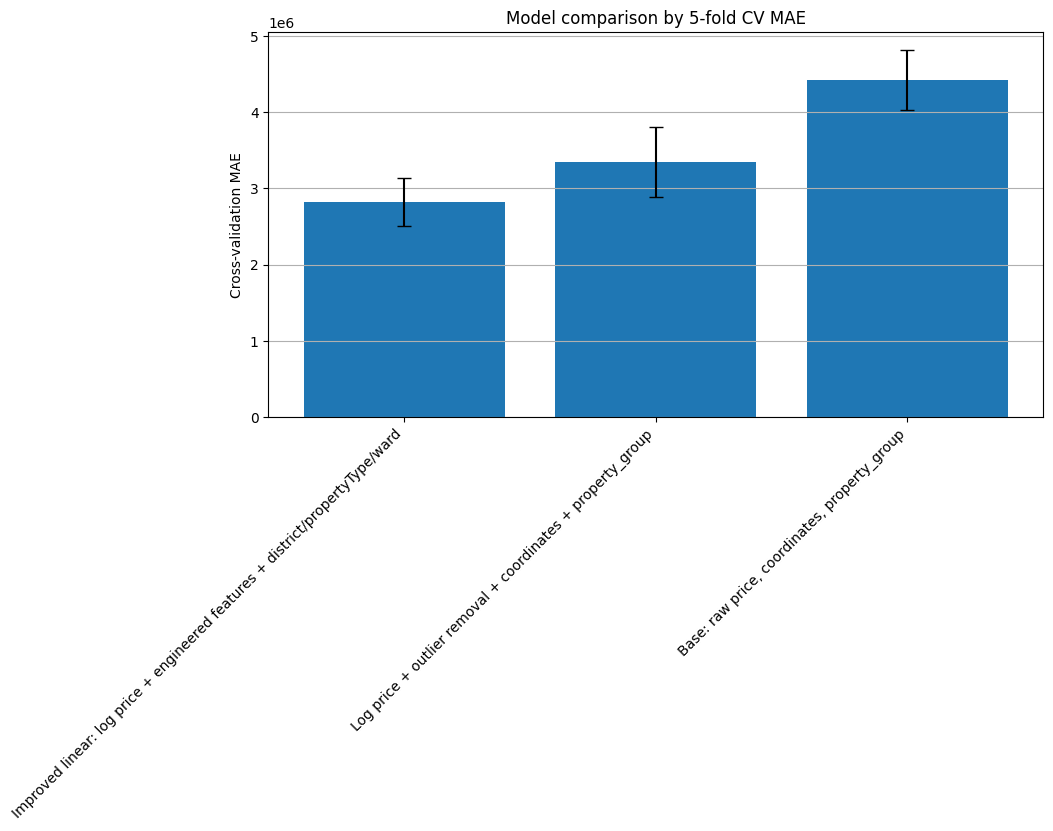

In [16]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["model"],
    comparison["MAE"],
    yerr=comparison["MAE_std"],
    capsize=5
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Cross-validation MAE")
plt.title("Model comparison by 5-fold CV MAE")
plt.grid(axis="y")

plt.show()

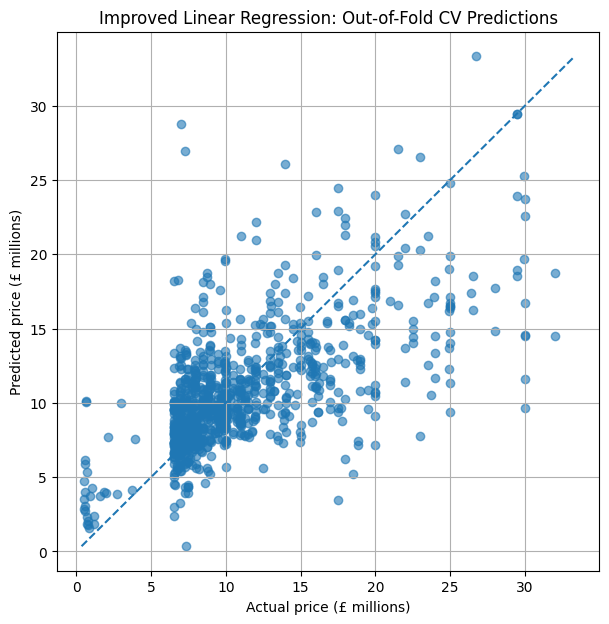

In [17]:
y_true = improved_data["y_test_price"].flatten()
y_pred = improved_predictions.flatten()

y_true_m = y_true / 1_000_000
y_pred_m = y_pred / 1_000_000

plt.figure(figsize=(7, 7))

plt.scatter(y_true_m, y_pred_m, alpha=0.6)

min_val = min(y_true_m.min(), y_pred_m.min())
max_val = max(y_true_m.max(), y_pred_m.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual price (£ millions)")
plt.ylabel("Predicted price (£ millions)")
plt.title("Improved Linear Regression: Out-of-Fold CV Predictions")
plt.grid(True)

plt.show()

In [18]:
absolute_errors = np.abs(y_true - y_pred)
errors_df = pd.DataFrame({
    "actual_price": y_true,
    "predicted_price": y_pred,
    "absolute_error": absolute_errors
})

errors_df["actual_price_m"] = errors_df["actual_price"] / 1_000_000
errors_df["predicted_price_m"] = errors_df["predicted_price"] / 1_000_000
errors_df["absolute_error_m"] = errors_df["absolute_error"] / 1_000_000

errors_df = errors_df.sort_values("absolute_error", ascending=False)

errors_df.head(10)

,actual_price,predicted_price,absolute_error,actual_price_m,predicted_price_m,absolute_error_m
166,7000000.0,28769808.00,21769808.00,7.00,28.769808,21.769808
790,30000000.0,9655776.00,20344224.00,30.00,9.655776,20.344224
362,7250000.0,26961500.00,19711500.00,7.25,26.961500,19.711500
204,30000000.0,11619930.00,18380070.00,30.00,11.619930,18.380070
205,32000000.0,14486524.00,17513476.00,32.00,14.486524,17.513476
780,25000000.0,9391458.00,15608542.00,25.00,9.391458,15.608542
2,30000000.0,14473682.00,15526318.00,30.00,14.473682,15.526318
1,30000000.0,14595828.00,15404172.00,30.00,14.595828,15.404172
13,23000000.0,7749885.50,15250114.50,23.00,7.749886,15.250115
221,17500000.0,3474719.75,14025280.25,17.50,3.474720,14.025280
